# Day 3 — MLP (makemore Part 2, video 3, 1h15m)

The bigram's fatal flaw: one character of context. This video: 3 characters of context → embedding table C → hidden layer → 27-way output. (Bengio et al. 2003, the paper that started neural language modeling.)

Big NEW concepts to watch for (none of these existed in my week so far):
- **Embeddings** — characters become learned vectors, not one-hots
- **Minibatches** — training on random subsets, not the full data every step
- **Learning-rate finding** — the principled way, not vibes
- **Train/dev/test splits and overfitting** — why one loss number stops being enough

MY exercises: dataset with context window, C lookup, hidden layer forward, loss (meet `F.cross_entropy`), minibatch training loop, splits, sampler. Boilerplate: loader + maps below (built them from memory twice — they're plumbing now).

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# HYPERPARAMETERS
BLOCK_SIZE = 3              # context length (chars of history)
EMBEDDINGS_DIMENSION = 2    # size of each character's learned vector
HIDDEN_WIDTH = 100          # neurons in the hidden layer
LEARNING_RATE = 0.12        # from my lr sweep (valley ~10^-1)
BATCH_SIZE = 32             # minibatch rows per step
STEPS = 10000               # training iterations

VOCAB_SIZE = 27             # forced by the data (26 letters + '.'), not a knob

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
def build_dataset(word_list, block_size):
    X, Y = [], []

    for word in word_list:
        context = [0] * block_size
        for ch in word + ".":
            ix = stoi[ch]
            Y.append(ix)
            X.append(context)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

In [7]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1],   BLOCK_SIZE)
Xdev, Ydev = build_dataset(words[n1:n2], BLOCK_SIZE)
Xte,  Yte  = build_dataset(words[n2:],   BLOCK_SIZE)

print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [8]:
Xtr.shape

torch.Size([182625, 3])

In [9]:
Ytr.shape

torch.Size([182625])

In [10]:
# we need to build look up table C, which is the embedding lookup table
g = torch.Generator().manual_seed(2147483647)
W1 = torch.randn(((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH)), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g)

# Layer two params
# For layer 2, there are 27 outputs.
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn((VOCAB_SIZE), generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

emb = C[Xtr]

In [11]:
emb.shape

torch.Size([182625, 3, 2])

In [12]:
O1 = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE) @ W1 + B1 # -1 is like telling pytorch to autofill the correct value
O1 = O1.tanh()
O1.shape

torch.Size([182625, 100])

In [13]:
logits = O1 @ W2 + B2

In [14]:
# count = logits.exp()
# prob = count/count.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
# loss

In [15]:
# Better way to calculate loss
loss = F.cross_entropy(logits, Ytr)
loss

tensor(21.9269, grad_fn=<NllLossBackward0>)

In [16]:
loss.backward()

In [17]:
for p in parameters:
    p.data += -LEARNING_RATE * p.grad

Now, all put together to tune the model

In [18]:
g = torch.Generator().manual_seed(2147483647)

# There are three inputs put into the initial neural network with two dimensions: 3 × 2 = 6.
W1 = torch.randn((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g) # 27 since there are 26 alphabets + 1 . special char

# Second layer
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn(VOCAB_SIZE, generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

for i in range(100):

    # Embedding lookup table where you can see the corresponding embedggings for any index in X from C
    emb = C[Xtr] # size -> [xyz, BLOCK_SIZE, EMBEDDINGS_DIMENSION]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)

    # Output of the first layer, which is the input to the second
    O1 = emb_view @ W1 + B1
    O1 = O1.tanh()
    logit = O1 @ W2 + B2
    loss = F.cross_entropy(logit, Ytr)

    print("loss is ", loss.item())

    for p in parameters:
        p.grad = None

    loss.backward()

    for p in parameters:
        p.data += -LEARNING_RATE * p.grad


loss is  21.9268798828125
loss is  19.568145751953125
loss is  17.914222717285156
loss is  16.396461486816406
loss is  14.940084457397461
loss is  14.030207633972168
loss is  13.345184326171875
loss is  12.647555351257324
loss is  11.765804290771484
loss is  11.02221393585205
loss is  10.412945747375488
loss is  9.867725372314453
loss is  9.466423988342285
loss is  8.975746154785156
loss is  8.655784606933594
loss is  8.211308479309082
loss is  7.937480449676514
loss is  7.594518661499023
loss is  7.344479084014893
loss is  7.057830333709717
loss is  6.830154895782471
loss is  6.590242385864258
loss is  6.383323669433594
loss is  6.183250427246094
loss is  6.001069068908691
loss is  5.830455780029297
loss is  5.672088623046875
loss is  5.524571895599365
loss is  5.387392520904541
loss is  5.259873867034912
loss is  5.141359806060791
loss is  5.0311079025268555
loss is  4.928384780883789
loss is  4.832461833953857
loss is  4.742700576782227
loss is  4.658519268035889
loss is  4.57943344

In [19]:
ix = 0
word = []
context = [0] * BLOCK_SIZE

while True:
    emb = C[torch.tensor(context)]
    O1 = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE) @ W1 + B1
    O1 = O1.tanh()

    context = context[1:] + [ix]

    logit = O1 @ W2 + B2
    # count = logit.exp()
    # prob = count/count.sum(1, keepdim=True)
    prob = F.softmax(logit, dim=1)

    ix = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()

    ch = itos[ix]

    word.append(ch)

    if ix == 0: 
        print(('').join(word))
        break


ayneiheahr.


In [20]:
# QUESTION: How do we find the best learning rate?
lre = torch.linspace(-3, 0, 1000) # Learning rate exponential: it's basically a range from -3 to 0, but when it gets exponentiated, it's from -0.001 to 1,000 steps.
lrs = 10**lre

In [21]:
Xtr.shape

torch.Size([182625, 3])

In [22]:
g = torch.Generator().manual_seed(2147483647)
lri = []
lossi = []

# forward pass
# There are three inputs put into the initial neural network with two dimensions: 3 × 2 = 6.
W1 = torch.randn((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g) # 27 since there are 26 alphabets + 1 . special char

# Second layer
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn(VOCAB_SIZE, generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

for i in range(1000):

    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    # Embedding lookup table where you can see the corresponding embedggings for any index in X from C
    emb = C[Xtr[ix]] # size -> [xyz, BLOCK_SIZE, EMBEDDINGS_DIMENSION]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)

    # Output of the first layer, which is the input to the second
    O1 = emb_view @ W1 + B1
    O1 = O1.tanh()
    logit = O1 @ W2 + B2
    loss = F.cross_entropy(logit, Ytr[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    lri.append(lre[i])
    lossi.append(loss.item())


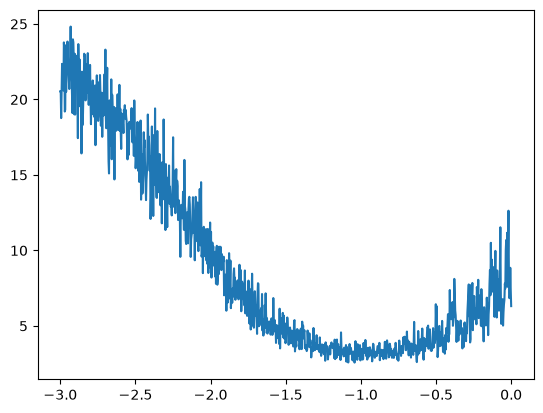

In [23]:
plt.plot(lri, lossi)
# From the graph, we can see that the best learning rate is around -1-ish. So we set that as a learning rate.
# lr = 10*-1

In [24]:
g = torch.Generator().manual_seed(2147483647)
lossi = []
stepi = []

# forward pass
# There are three inputs put into the initial neural network with two dimensions: 3 × 2 = 6.
W1 = torch.randn((EMBEDDINGS_DIMENSION * BLOCK_SIZE, HIDDEN_WIDTH), generator=g)
B1 = torch.randn(HIDDEN_WIDTH, generator=g)
C = torch.randn((VOCAB_SIZE, EMBEDDINGS_DIMENSION), generator=g) # 27 since there are 26 alphabets + 1 . special char

# Second layer
W2 = torch.randn((HIDDEN_WIDTH, VOCAB_SIZE), generator=g)
B2 = torch.randn(VOCAB_SIZE, generator=g)

parameters = [W1, B1, W2, B2, C]

for p in parameters:
    p.requires_grad = True

for i in range(STEPS):

    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    # Embedding lookup table where you can see the corresponding embedggings for any index in X from C
    emb = C[Xtr[ix]] # size -> [xyz, BLOCK_SIZE, EMBEDDINGS_DIMENSION]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)

    # Output of the first layer, which is the input to the second
    O1 = emb_view @ W1 + B1
    O1 = O1.tanh()
    logit = O1 @ W2 + B2
    loss = F.cross_entropy(logit, Ytr[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = LEARNING_RATE
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    stepi.append(i)
    lossi.append(loss.item())

print(loss.item())

2.1927764415740967


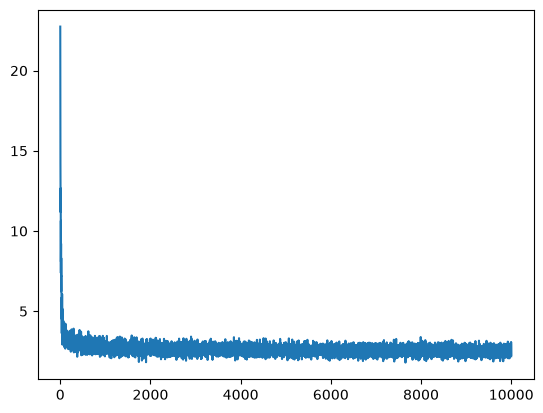

In [25]:
plt.plot(stepi, lossi)

## EXERCISE — the leaderboard (dev loss is the only score that counts)

| model | dev loss |
|---|---|
| uniform ignorance | 3.29 |
| bigram (counting, part 1) | 2.45 |
| **mine, honest baseline** (emb 2, hidden 100, 10k steps, lr 0.12) | **2.499** (train 2.500 — train ≈ dev = underfitting, model too small/undertrained) |
| lecture, same-size model trained longer | ~2.3 |
| lecture final (emb 10, hidden 200, ~200k steps + lr decay) | **2.17** |

**CURRENT GOAL: beat the bigram — dev < 2.45.** I have NOT beaten it yet (2.499 > 2.454): a 3,481-param neural net with 3 chars of context currently loses to a counting table with 1 char. More capacity/training needed.
Then: ~2.3 (lecture same-size), then **2.17 — Karpathy's on-camera challenge to viewers.**
Rules: knobs in the dashboard only · judge on dev only · test stays sealed until the final model.

In [26]:
@torch.no_grad()
def split_loss(X, Y):
    emb = C[X]
    emb_view = emb.view(-1, EMBEDDINGS_DIMENSION * BLOCK_SIZE)
    O1 = (emb_view @ W1 + B1).tanh()
    logit = O1 @ W2 + B2
    return F.cross_entropy(logit, Y).item()

# train set
print("train loss:", split_loss(Xtr, Ytr))
# dev set
print("dev loss:  ", split_loss(Xdev, Ydev))

train loss: 2.4999184608459473
dev loss:   2.4985315799713135
